In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.linear_model import SGDRegressor,LinearRegression
from sklearn.metrics import r2_score

In [45]:
X = 6*np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.rand(200,1)

In [46]:
print(X.shape)
print(y.shape)

(200, 1)
(200, 1)


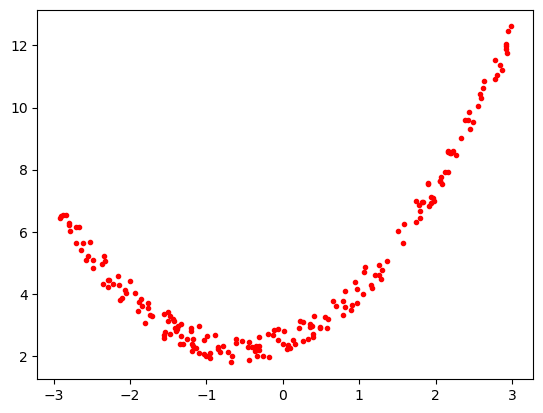

<Figure size 800x400 with 0 Axes>

In [48]:
plt.plot(X,y,'r.')
plt.figure(figsize=(8,4)) 
plt.show()
#plt.resize(10,5)

In [49]:
X_train ,X_test,y_train,y_test = train_test_split(X,y,random_state =2,test_size=0.2)

In [50]:
lr = LinearRegression()

In [51]:
lr.fit(X_train,y_train)

LinearRegression()

In [53]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.49437944795488864

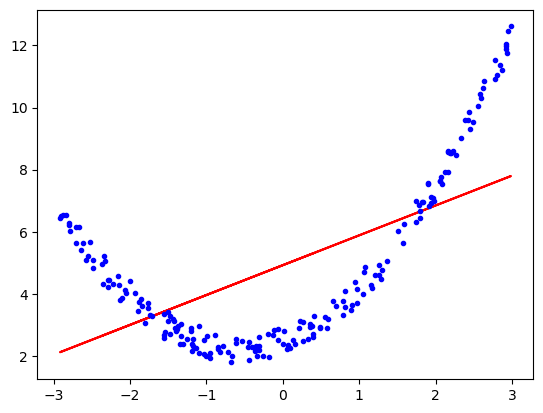

In [58]:
plt.plot(X_train,lr.predict(X_train),color ='r')
plt.plot(X,y, "b.")
plt.show()

In [66]:
poly = PolynomialFeatures(degree=2,include_bias=True)

In [67]:
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [70]:
print(X_train[0])
print(X_train_trans[0])

[-2.37031727]
[ 1.         -2.37031727  5.61840397]


In [73]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [74]:
y_pred = lr.predict(X_test_trans)

In [75]:
r2_score(y_test,y_pred)

0.9891579780880794

In [76]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

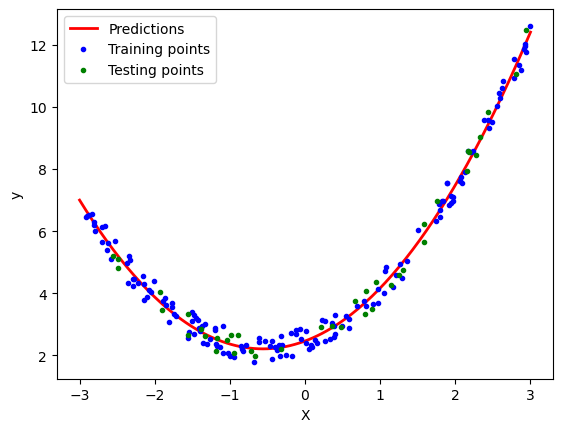

In [77]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()